 Classification des entreprises en difficulté (Méthodologie CRISP-DM)
* Analyse du  dataset et identification d' une des caractéristique à classifier
* Analyse les données
* Préparation  et nettoyage des données
* Conception de modèle qui est capable de classifier de nouvelles données
* Éléments à explorer : 
* Affichage de la courbe ROC
* Affichage des métriques pendant l’apprentissage : précision, rappel, accuracy
* Affichage de la matrice de confusion à la fin

Ce travail a porté sur la classification des entreprises selon leur santé financière. Il s'agit de prédire sur la base de ratio financier les entreprises qui pourraient être en faillite (difficultées).
La dataset que nous avons utilisé provient du site (https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction). 
Les données ont été collectées du Journal Econique due TAIWAN sur la période 1999 à 2009. Les entreprises ont été classifiées "Saine" ou "en faillite" sur la base des règles d'évaluation de la bourse de TAIWAN.
Le dataset est sous licence " a Creative Commons Attribution 4.0 International (CC BY 4.0)". 
il semble qu'il n'ait pas de données manquantes. Les données concernes les entreprises au nombre de 6819 avec des variables explicatives au nombre de 95 toutes des valeurs continues.
La variable cible est "Bankrupt?, qui est ici binaire 0: entreprise saine et 1: entreprise en faillite ou en difficultée.

ANALYSE DU DATASET

In [1]:
import pandas as pd
import numpy as np
T_data = pd.read_csv("/Users/benothmane/Desktop/Algo_Machine_learning_tp/data_bank.csv")
T_data.head()  

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


Comme on peut le constater, il s'agit principalement de donnée financière, en l'occurence les ratios financiers des entreprises sur une période allant de 1999 à 2009. 
Cependant l'année ou l'exercice n'est pas mentionné dans le dataset. On serait donc entrain d'analyser des entreprises qui n'ont pas été dans les mêmes conditions économiques (variable macroéconomique ou même microéconomique qui aurait pu impacter les ratios que nous avons dans les données).

In [2]:
T_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

L'affichage du nom de façon explicite des colonnes nous permet d'apprécier la diverssité des formats des variables explicatives.
nous avons des noms de variables avec des virgules et des espaces, ce qui pourrait conduire à des difficultés de traitement.
Nous allons les mettre au même format, en changeant les noms de variables en RATIO1 jusqu'à RATIO9( avec une tableau de matière expliquant le ratio.

In [3]:
uniques = T_data["Bankrupt?"].unique()
uniques

array([1, 0])

Nous confirmons ici que la variable cible "Bankrupt?" , ne contient que deux catégories (0 pour sain et 1 pour faillite). Il n'y a pas de valeur manquante comme noté par le site de référence.

In [4]:
T_data.isna().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

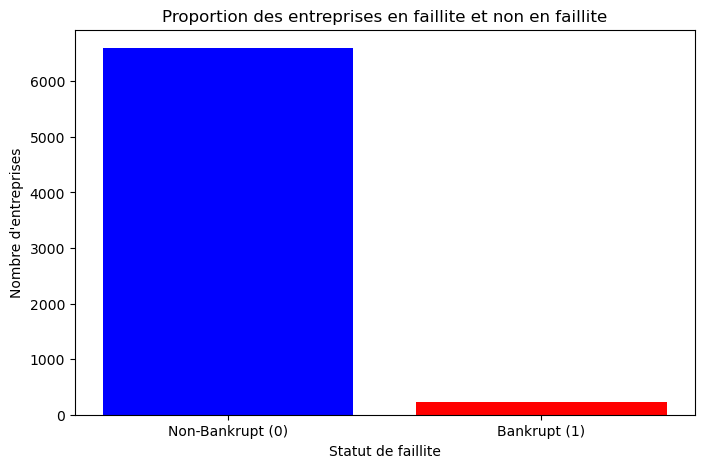

In [5]:
import matplotlib.pyplot as plt

# Comptage des valeurs de "Bankrupt?"
bankrupt_counts = T_data["Bankrupt?"].value_counts()

# Création du barplot avec couleurs personnalisées
plt.figure(figsize=(8, 5))
plt.bar(bankrupt_counts.index, bankrupt_counts.values, color=["blue", "red"])

# Ajout de titres et labels
plt.title("Proportion des entreprises en faillite et non en faillite")
plt.xlabel("Statut de faillite")
plt.ylabel("Nombre d'entreprises")
plt.xticks(ticks=[0, 1], labels=["Non-Bankrupt (0)", "Bankrupt (1)"])

# Affichage du graphique
plt.show()

Notre dataset est très déséquilibrée. moins de 25% des données concernent la valeur que nous souhaitons prédire (donc anticiper). Si nous exploitons tel quel, ce dataset, nous aurons certainement une surépresentation des entreprises saines. Nous avons donc entreprise d'équilibrer notre dataset. Nous avons donc décidé de selectionner de façon aléatoire 60% des sociétés saines et 40% des sociétés en difficultés du dataset d'origine pour construire un nouveau dataset sur lequel nous allons construire notre modèle. Il est bon de rappeler que nous néanmoins lancée un modèle sur la dataset entière afin de valider notre décision d'équilibrer les données. Le modèle était bon à 97% dans la détection des entreprises saines et 63% dans la détection des entreprises en faillite avec un taux de rappel de 26% pour la détection des entreprises en difficultées.

 Rééchantillonnage du dataset puis Renommage des variables 

In [6]:
from sklearn.utils import resample
import seaborn as sns
# Split des faillites et non-faillites
df_bankrupt = T_data[T_data["Bankrupt?"] == 1]  
df_non_bankrupt = T_data[T_data["Bankrupt?"] == 0]  

#  nombre d'échantillons de non-faillites
nb_0 = 220  # 50% du total (220  et 220)

# Sous-échantillonnage des non-faillites
df_non_bankrupt_resampled = resample(df_non_bankrupt, replace=False, n_samples=nb_0, random_state=42)

# Concaténation des faillites (1) et les non-faillites (0)
T_data_balanced = pd.concat([df_bankrupt, df_non_bankrupt_resampled])

#  distribution
print(T_data_balanced["Bankrupt?"].value_counts(normalize=True)) 
print(T_data_balanced["Bankrupt?"].value_counts())

T_data_balanced.to_csv("/Users/benothmane/Desktop/Algo_Machine_learning_tp/balanced_data2.csv", index=False)
T_data_balanced


Bankrupt?
1    0.5
0    0.5
Name: proportion, dtype: float64
Bankrupt?
1    220
0    220
Name: count, dtype: int64


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5690,0,0.512797,0.567543,0.559827,0.604282,0.604282,0.999065,0.797494,0.809388,0.303506,...,0.813528,0.002994,0.623845,0.604277,0.841845,0.282856,0.026930,0.565743,1,0.022074
2564,0,0.546970,0.592673,0.595535,0.614429,0.614429,0.999008,0.797439,0.809354,0.303530,...,0.829396,0.030086,0.623683,0.614426,0.843295,0.282088,0.026820,0.565290,1,0.023302
4914,0,0.581241,0.599760,0.625194,0.617514,0.617514,0.999192,0.797657,0.809550,0.303526,...,0.830678,0.002959,0.622419,0.617513,0.842355,0.277674,0.026805,0.565225,1,0.042582
6596,0,0.499196,0.562745,0.550511,0.614199,0.614199,0.999034,0.797479,0.809394,0.303546,...,0.817406,0.003369,0.623971,0.614196,0.841433,0.277423,0.026806,0.565227,1,0.045542


Bankrupt?
1    0.5
0    0.5
Name: proportion, dtype: float64
Bankrupt?
1    220
0    220
Name: count, dtype: int64


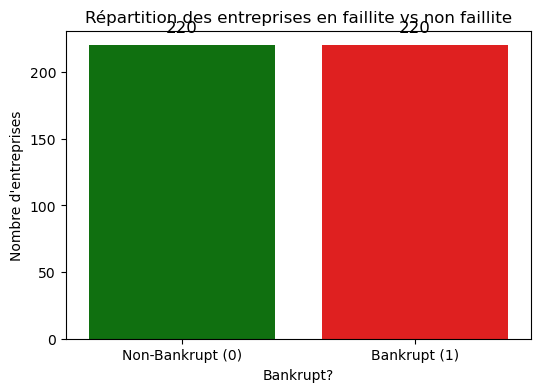

Nombre de variables et de lignes: 


(440, 96)

In [7]:

#  distribution de la cible à classifier dans le datset équilibré
print(T_data_balanced["Bankrupt?"].value_counts(normalize=True)) 
print(T_data_balanced["Bankrupt?"].value_counts())
T_data_balanced.head()

#  occurrences de chaque classe
bankrupt_counts = T_data_balanced["Bankrupt?"].value_counts().reset_index()
bankrupt_counts.columns = ["Bankrupt?", "Count"]

# Diagramme en barres avec la bonne syntaxe
plt.figure(figsize=(6, 4))
sns.barplot(data=bankrupt_counts, x="Bankrupt?", y="Count", hue="Bankrupt?", palette=["green", "red"], legend=False)

# étiquettages
plt.xticks([0, 1], ["Non-Bankrupt (0)", "Bankrupt (1)"])
plt.ylabel("Nombre d'entreprises")
plt.title("Répartition des entreprises en faillite vs non faillite")

# Afficher les valeurs sur les barres
for i, val in enumerate(bankrupt_counts["Count"]):
    plt.text(i, val + 10, str(val), ha='center', fontsize=12)

plt.show()
print("Nombre de variables et de lignes: ")
T_data_balanced.shape

In [8]:
#Affichage des données équilibrées
T_data_balanced.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [9]:
 #Copie des anciens noms (hors 'Bankrupt?')
old_names = [col for col in T_data_balanced.columns if col != "Bankrupt?"]

# Génération des nouveaux noms
new_names = [f"Ratio{i}" for i in range(1, len(old_names) + 1)]

# Dictionnaire de correspondance
correspondance_dict = dict(zip(old_names, new_names))

# Application des nouveaux noms (en gardant 'Bankrupt?' intact)
T_data_balanced.rename(columns=correspondance_dict, inplace=True)

# Création du tableau de correspondance sous forme de DataFrame
correspondance_df = pd.DataFrame({
    "Ancien nom": correspondance_dict.keys(),
    "Nouveau nom": correspondance_dict.values()
})

# Sauvegarde du  dataset renommé
output_path = "/Users/benothmane/Desktop/Algo_Machine_learning_tp/fair_data.csv"
T_data_balanced.to_csv(output_path, index=False)

#Tableau de correspondance
print("Tableau de correspondance des variables :")
print(correspondance_df)

# Affichage des premières lignes du dataset renommé
print("Dataset après renommage :")
T_data_balanced.head()


Tableau de correspondance des variables :
                                           Ancien nom Nouveau nom
0    ROA(C) before interest and depreciation befor...      Ratio1
1              ROA(A) before interest and % after tax      Ratio2
2    ROA(B) before interest and depreciation after...      Ratio3
3                              Operating Gross Margin      Ratio4
4                         Realized Sales Gross Margin      Ratio5
..                                                ...         ...
90                                Liability to Equity     Ratio91
91                 Degree of Financial Leverage (DFL)     Ratio92
92   Interest Coverage Ratio (Interest expense to ...     Ratio93
93                                    Net Income Flag     Ratio94
94                                Equity to Liability     Ratio95

[95 rows x 2 columns]
Dataset après renommage :


,Bankrupt?,Ratio1,Ratio2,Ratio3,Ratio4,Ratio5,Ratio6,Ratio7,Ratio8,Ratio9,...,Ratio86,Ratio87,Ratio88,Ratio89,Ratio90,Ratio91,Ratio92,Ratio93,Ratio94,Ratio95
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [10]:
#informations numériques du dataset
T_data_balanced.describe()

,Bankrupt?,Ratio1,Ratio2,Ratio3,Ratio4,Ratio5,Ratio6,Ratio7,Ratio8,Ratio9,...,Ratio86,Ratio87,Ratio88,Ratio89,Ratio90,Ratio91,Ratio92,Ratio93,Ratio94,Ratio95
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,...,440.000000,4.400000e+02,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.0,440.000000
mean,0.500000,0.464047,0.511214,0.510182,0.603219,0.603222,0.998864,0.797033,0.808906,0.303120,...,0.773796,4.550000e+07,0.623439,0.603217,0.832935,0.287003,0.028255,0.565078,1.0,0.035736
std,0.500569,0.088335,0.108296,0.095765,0.014974,0.014974,0.000572,0.002351,0.003030,0.003754,...,0.081859,5.976066e+08,0.006080,0.014974,0.055051,0.049461,0.014219,0.004928,0.0,0.048416
min,0.000000,0.024277,0.000000,0.033514,0.502623,0.502623,0.991888,0.757216,0.761550,0.235090,...,0.000000,0.000000e+00,0.549597,0.502622,0.000000,0.000000,0.020760,0.515779,1.0,0.003946
25%,0.000000,0.432750,0.475319,0.481584,0.596695,0.596706,0.998862,0.797106,0.809050,0.303293,...,0.760256,1.144897e-03,0.623183,0.596693,0.836122,0.278188,0.026638,0.564447,1.0,0.018302
50%,0.500000,0.474845,0.535706,0.525617,0.602163,0.602228,0.998973,0.797383,0.809307,0.303454,...,0.795971,2.745159e-03,0.623716,0.602160,0.840083,0.281686,0.026791,0.565158,1.0,0.023608
75%,1.000000,0.506106,0.565730,0.558756,0.610235,0.609886,0.999045,0.797484,0.809396,0.303540,...,0.813196,7.693085e-03,0.624095,0.610235,0.841581,0.286423,0.026880,0.565682,1.0,0.036890
max,1.000000,0.754643,0.954536,0.810268,0.665151,0.665151,0.999554,0.805640,0.817080,0.321553,...,1.000000,9.170000e+09,0.679654,0.665149,1.000000,1.000000,0.264577,0.624147,1.0,0.798122


IDENTIFICATION DES VALEURS MANQUANTES 

In [11]:
# Création du tableau de résumé
summary_df = pd.DataFrame({
    "Colonnes": T_data_balanced.columns,
    "Valeurs uniques": T_data_balanced.nunique().values,
    "Valeurs manquantes": T_data_balanced.isna().sum().values,
    })

# Affichage du tableau
print("Résumé des données :")
summary_df

Résumé des données :


,Colonnes,Valeurs uniques,Valeurs manquantes
0,Bankrupt?,2,0
1,Ratio1,424,0
2,Ratio2,418,0
3,Ratio3,416,0
4,Ratio4,418,0
...,...,...,...
91,Ratio91,440,0
92,Ratio92,425,0
93,Ratio93,425,0
94,Ratio94,1,0


IDENTIFICATION DES VALEURS ABERRANTES

In [12]:
# Calcul des quartiles et de l'IQR
Q1 = T_data_balanced.quantile(0.25)
Q3 = T_data_balanced.quantile(0.75)
IQR = Q3 - Q1

# Détection des valeurs aberrantes
outliers_mask = ((T_data_balanced < (Q1 - 1.5 * IQR)) | (T_data_balanced > (Q3 + 1.5 * IQR)))

# Comptage des valeurs aberrantes par colonne
outliers_count = outliers_mask.sum()

# Création d'un DataFrame récapitulatif
outliers_summary = pd.DataFrame({
    "Colonnes": T_data_balanced.columns,
    "Nombre de valeurs aberrantes": outliers_count.values
})

# Filtrer pour afficher uniquement les colonnes contenant des valeurs aberrantes
outliers_summary = outliers_summary[outliers_summary["Nombre de valeurs aberrantes"] > 0]

# Affichage du tableau final
print("Nombre de valeurs aberrantes par colonne :")
outliers_summary

Nombre de valeurs aberrantes par colonne :


,Colonnes,Nombre de valeurs aberrantes
1,Ratio1,37
2,Ratio2,36
3,Ratio3,39
4,Ratio4,25
5,Ratio5,25
...,...,...
90,Ratio90,46
91,Ratio91,31
92,Ratio92,91
93,Ratio93,94


ANALYSES STATISTIQUES DU DATASET

In [13]:
# Test de PEARSON
from scipy import stats
# Filtre des colonnes constantes
variable_columns = [col for col in T_data_balanced.columns if T_data_balanced[col].nunique() > 1 and col != 'Bankrupt?']

# Liste pour stocker les résultats
results = []

# Calcul de la corrélation de Pearson pour les colonnes valides
for column in variable_columns:
    correlation, p_value = stats.pearsonr(T_data_balanced[column], T_data_balanced['Bankrupt?'])
    results.append({'Variable': column, 'Corrélation': correlation, 'p-value': p_value})

# Convertir en DataFrame
df_corr = pd.DataFrame(results)

# Affichage du  DataFrame
print("Resultats avec le test de PEARSON")
df_corr

Resultats avec le test de PEARSON


,Variable,Corrélation,p-value
0,Ratio1,-0.516164,2.499294e-31
1,Ratio2,-0.501674,2.010014e-29
2,Ratio3,-0.509103,2.175940e-30
3,Ratio4,-0.304073,7.266795e-11
4,Ratio5,-0.301173,1.119651e-10
...,...,...,...
89,Ratio90,-0.125971,8.159154e-03
90,Ratio91,0.133087,5.171439e-03
91,Ratio92,0.013256,7.815658e-01
92,Ratio93,-0.024195,6.127544e-01


In [14]:
#Test de Khi2

#  variables catégorielles et la cible?
X = T_data_balanced.drop(columns=['Bankrupt?'])  # Exclure la variable cible
y = T_data_balanced['Bankrupt?']  # Variable cible

# variables sont encore catégorielles
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']

# variables catégorielles?
if len(categorical_cols) == 0:
    print("Aucune variable catégorielle détectée pour le test Chi2.")
else:
    # tocker les p-values
    chi2_results = {}

    # test Chi2 sur chaque variable catégorielle
    for column in categorical_cols:
        chi2_stat, p_value = chi2(X[[column]], y)
        chi2_results[column] = p_value[0]  # Stocker la p-value

    # variables pertinentes basées sur le test Chi2 (p < 0.05)
    threshold_chi2 = 0.05
    relevant_features_chi2 = [col for col, p in chi2_results.items() if p < threshold_chi2]

    print("Variables pertinentes basées sur le test du Chi2:", relevant_features_chi2)

Aucune variable catégorielle détectée pour le test Chi2.


In [15]:
# Test ANAOVA
# Liste pour stocker les résultats
anova_results = []

# Exclure les colonnes constantes dans les 2 groupes
variable_columns = []
for col in T_data_balanced.columns:
    if col != "Bankrupt?":
        unique_vals_0 = T_data_balanced[T_data_balanced["Bankrupt?"] == 0][col].nunique()
        unique_vals_1 = T_data_balanced[T_data_balanced["Bankrupt?"] == 1][col].nunique()
        if unique_vals_0 > 1 and unique_vals_1 > 1:  # Vérifie que la colonne n'est pas constante
            variable_columns.append(col)

# Test ANOVA pour chaque variable restante
for column in variable_columns:
    f_statistic, p_value = stats.f_oneway(
        T_data_balanced[T_data_balanced['Bankrupt?'] == 0][column],  
        T_data_balanced[T_data_balanced['Bankrupt?'] == 1][column]  
    )
    anova_results.append({'Variable': column, 'F-statistic': f_statistic, 'p-value': p_value})

# Convertir en DataFrame et trier par p-value
df_anova = pd.DataFrame(anova_results).sort_values(by='p-value')

# Affichage du DataFrame
print("Resultats avec le test ANOVA")
df_anova

Resultats avec le test ANOVA


,Variable,F-statistic,p-value
36,Ratio37,219.327749,1.606681e-40
37,Ratio38,219.327749,1.606681e-40
18,Ratio19,188.728827,5.776924e-36
42,Ratio43,186.091372,1.461848e-35
22,Ratio23,180.687320,9.919739e-35
...,...,...,...
86,Ratio88,0.123904,7.250078e-01
61,Ratio62,0.077530,7.808042e-01
90,Ratio92,0.076978,7.815658e-01
10,Ratio11,0.030252,8.619990e-01


In [16]:
#Test KS
# Liste pour stocker les résultats
ks_results = []

# Test KS pour chaque variable (sauf 'Bankrupt?')
for column in T_data_balanced.drop('Bankrupt?', axis=1).columns:
    stat, p_value = stats.ks_2samp(
        T_data_balanced[T_data_balanced['Bankrupt?'] == 0][column], 
       T_data_balanced[T_data_balanced['Bankrupt?'] == 1][column]
    )
    ks_results.append({'Variable': column, 'KS-statistic': stat, 'p-value': p_value})

# Convertir en DataFrame et trier par p-value
df_ks = pd.DataFrame(ks_results).sort_values(by='p-value')

# Afficher les résultats triés
print(df_ks)

# Afficher uniquement les variables significatives (p < 0.05)
relevant_features_ks = df_ks[df_ks['p-value'] < 0.05]
print("\nVariables pertinentes basées sur le test KS (p < 0.05) :")
relevant_features_ks

   Variable  KS-statistic       p-value
85  Ratio86      0.650000  3.802788e-44
42  Ratio43      0.645455  1.769759e-43
22  Ratio23      0.645455  1.769759e-43
68  Ratio69      0.636364  3.659425e-42
6    Ratio7      0.636364  3.659425e-42
..      ...           ...           ...
49  Ratio50      0.081818  4.539272e-01
63  Ratio64      0.077273  5.282454e-01
76  Ratio77      0.077273  5.282454e-01
84  Ratio85      0.027273  9.999979e-01
93  Ratio94      0.000000  1.000000e+00

[95 rows x 3 columns]

Variables pertinentes basées sur le test KS (p < 0.05) :


,Variable,KS-statistic,p-value
85,Ratio86,0.650000,3.802788e-44
42,Ratio43,0.645455,1.769759e-43
22,Ratio23,0.645455,1.769759e-43
68,Ratio69,0.636364,3.659425e-42
6,Ratio7,0.636364,3.659425e-42
...,...,...,...
48,Ratio49,0.195455,4.323392e-04
62,Ratio63,0.186364,9.349937e-04
75,Ratio76,0.177273,1.947473e-03
11,Ratio12,0.159091,7.551826e-03


In [17]:
#Test de normalité
# Selection des colonnes avec au moins 2 valeurs uniques
variable_columns = [col for col in T_data_balanced.columns if col != 'Bankrupt?' and T_data_balanced[col].nunique() > 1]

# Stock les résultats
results = []

# Test de normalité de Shapiro-Wilk
for column in variable_columns:
    stat, p_value = stats.shapiro(T_data_balanced[column])
    results.append({'Variable': column, 'Statistique': stat, 'p-value': p_value})

# Convertir en DataFrame
df_normality = pd.DataFrame(results)

# Afficher le DataFrame
print("test de  normalité avec  Shapiro-Wilk")
df_normality

test de  normalité avec  Shapiro-Wilk


,Variable,Statistique,p-value
0,Ratio1,0.913444,3.556854e-15
1,Ratio2,0.860215,2.169777e-19
2,Ratio3,0.888547,2.501415e-17
3,Ratio4,0.861901,2.818505e-19
4,Ratio5,0.859733,2.014269e-19
...,...,...,...
89,Ratio90,0.211191,2.659712e-39
90,Ratio91,0.225030,4.632679e-39
91,Ratio92,0.100047,4.033845e-41
92,Ratio93,0.508205,3.916557e-33


Les résultats montrent que toutes les p-values sont très faibles (<< 0.05), ce qui signifie que les variables ne suivent pas une distribution normale.

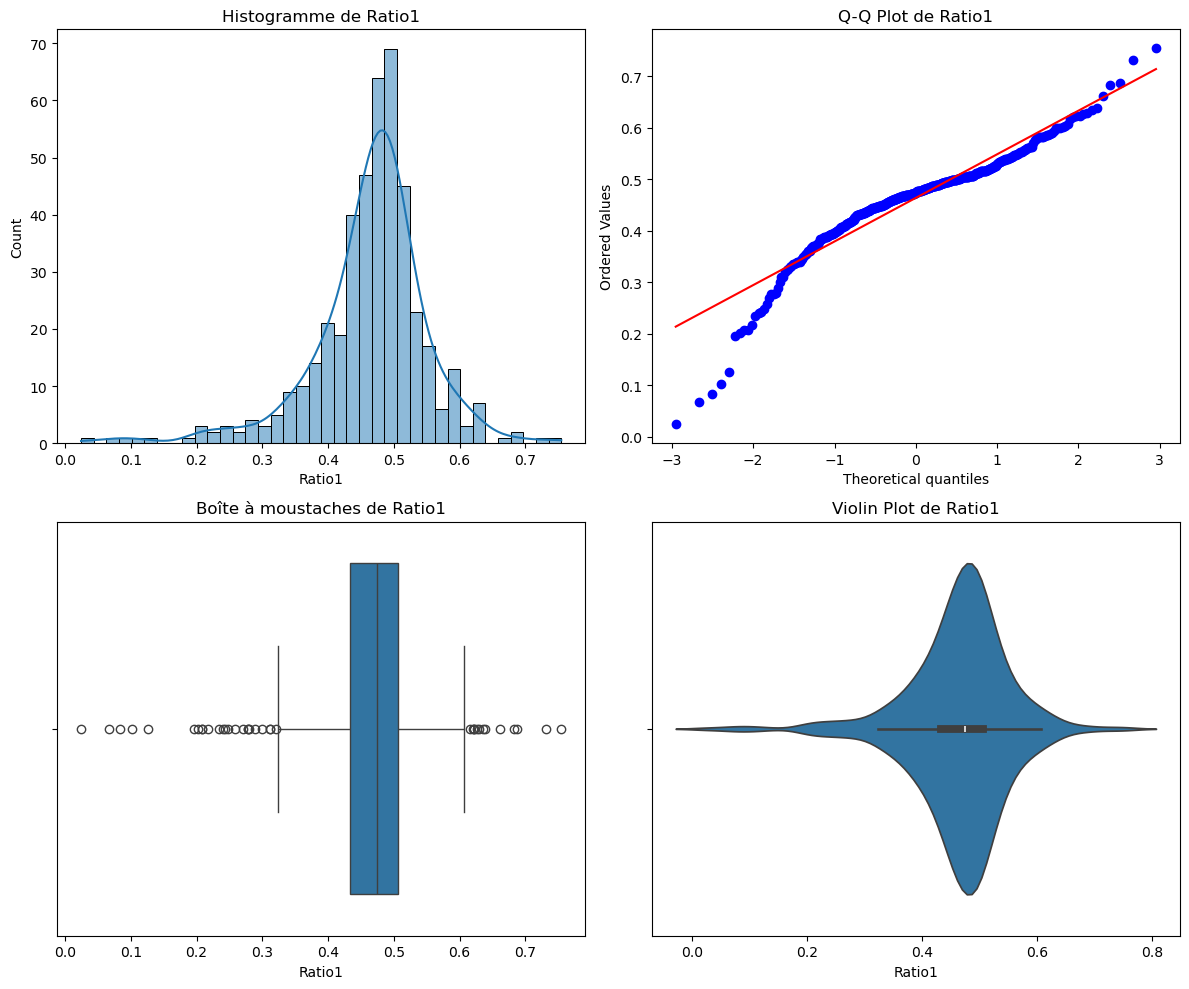

Résultats du test de normalité :


,Variable,Skewness,Kurtosis
0,Ratio1,-1.162365,4.223316
1,Ratio2,-1.442924,4.793988
2,Ratio3,-1.414080,4.874103
3,Ratio4,-0.879591,8.881812
4,Ratio5,-0.869136,8.919178
...,...,...,...
89,Ratio90,-10.394221,137.905372
90,Ratio91,9.255627,122.115042
91,Ratio92,13.535740,200.067190
92,Ratio93,1.634278,70.389257


In [18]:
# Sélection des colonnes numériques (hors "Bankrupt?")
numeric_columns = [col for col in T_data_balanced.columns if col != 'Bankrupt?']

# Filtre des colonnes avec une seule valeur unique (constantes)
valid_columns = [col for col in numeric_columns if T_data_balanced[col].nunique() > 1]

# Stockage des résultats des tests
normality_results = []

# Création des graphiques pour la première variable valide uniquement
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
first_var = valid_columns[0]  # première variable valide pour l'affichage

for col in valid_columns:
    data = T_data_balanced[col].dropna()  # Supprimer les valeurs manquantes
    
   
    
    # Vérifieons  si les données sont quasi constantes (évite les erreurs de skew/kurtosis)
    if data.nunique() > 1:
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)
    else:
        skewness, kurtosis = np.nan, np.nan  # Valeurs non calculables
    
    normality_results.append({
        "Variable": col,
        
        "Skewness": skewness,
        "Kurtosis": kurtosis
    })
    
    # Visualisation pour la première variable uniquement
    if col == first_var:
        sns.histplot(data, kde=True, ax=axes[0, 0])
        axes[0, 0].set_title(f"Histogramme de {col}")

        stats.probplot(data, dist="norm", plot=axes[0, 1])
        axes[0, 1].set_title(f"Q-Q Plot de {col}")

        sns.boxplot(x=data, ax=axes[1, 0])
        axes[1, 0].set_title(f"Boîte à moustaches de {col}")

        sns.violinplot(x=data, ax=axes[1, 1])
        axes[1, 1].set_title(f"Violin Plot de {col}")

plt.tight_layout()
plt.show()

# Conversion en DataFrame pour afficher les résultats sous forme de tableau
data_normality = pd.DataFrame(normality_results)

# Affichage du tableau des résultats
print("Résultats du test de normalité :")
data_normality


In [19]:
#Test de correlation SPEARMANN
# Filtre des  colonnes valides (exclure 'Bankrupt?' et les colonnes constantes)
variable_columns = [col for col in T_data_balanced.columns if T_data_balanced[col].nunique() > 1 and col != 'Bankrupt?']

# Liste pour stocker les résultats
results = []

# Calcul de la corrélation de Spearman
for column in variable_columns:
    correlation, p_value = stats.spearmanr(T_data_balanced[column], T_data_balanced['Bankrupt?'])
    results.append({'Variable': column, 'Corrélation SPEARMANN': correlation, 'p-value': p_value})

# Convertir en DataFrame
df_spearman = pd.DataFrame(results)

# Afficher le DataFrame
print("Résultats du test de SPEARMANN:")
df_spearman


Résultats du test de SPEARMANN:


,Variable,Corrélation SPEARMANN,p-value
0,Ratio1,-0.638732,8.245353e-52
1,Ratio2,-0.645048,3.983333e-53
2,Ratio3,-0.642149,1.614362e-52
3,Ratio4,-0.407481,4.974751e-19
4,Ratio5,-0.403473,1.177400e-18
...,...,...,...
89,Ratio90,-0.629123,7.245366e-50
90,Ratio91,0.569252,3.760009e-39
91,Ratio92,-0.424525,1.117477e-20
92,Ratio93,-0.345793,8.375516e-14


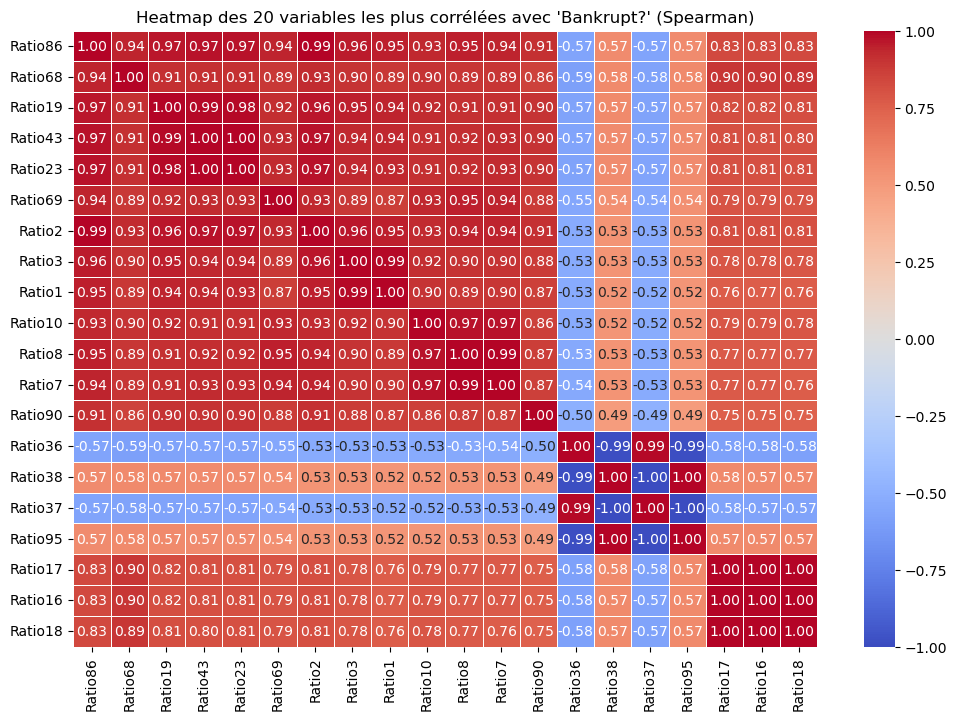

In [20]:
# Filtre des colonnes valides (exclure 'Bankrupt?' et les colonnes constantes)
variable_columns = [col for col in T_data_balanced.columns if T_data_balanced[col].nunique() > 1]

# Calcul de la matrice de corrélation Spearman
spearman_corr = T_data_balanced[variable_columns].corr(method="spearman")

# Sélectionner les 20 variables les plus corrélées avec 'Bankrupt?'
top_20_vars = spearman_corr["Bankrupt?"].abs().sort_values(ascending=False).index[1:21]  # On exclut 'Bankrupt?' lui-même

# Filtre de  la matrice pour ne garder que ces variables
top_20_corr_matrix = spearman_corr.loc[top_20_vars, top_20_vars]

# Affichage de la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(top_20_corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Heatmap des 20 variables les plus corrélées avec 'Bankrupt?' (Spearman)")
plt.show()

NORMALISATION DU DATASET


In [21]:
from sklearn.preprocessing import PowerTransformer, RobustScaler

# Exclusion de la colonne cible 'Bankrupt?'
X = T_data_balanced.drop(columns=['Bankrupt?'])

# RobustScaler pour réduire l'impact des valeurs extrêmes
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

# PowerTransformer (Yeo-Johnson)
scaler_YJ = PowerTransformer(method='yeo-johnson')
X_transformed = scaler_YJ.fit_transform(X_robust)

# Conversion du  DataFrame avec les mêmes noms de colonnes
T_data_YJ = pd.DataFrame(X_transformed, columns=X.columns)

# Ajout de  la colonne 'Bankrupt?' de l'original
T_data_YJ['Bankrupt?'] = T_data_balanced['Bankrupt?'].values

# Sauvegarde du dataset normalisé
output_path = "/Users/benothmane/Desktop/Algo_Machine_learning_tp/T_data_YJ.csv"
T_data_YJ.to_csv(output_path, index=False)
print(f"Fichier sauvegardé sous : {output_path}")
# Afficher un aperçu
T_data_YJ.head()

Fichier sauvegardé sous : /Users/benothmane/Desktop/Algo_Machine_learning_tp/T_data_YJ.csv


,Ratio1,Ratio2,Ratio3,Ratio4,Ratio5,Ratio6,Ratio7,Ratio8,Ratio9,Ratio10,...,Ratio87,Ratio88,Ratio89,Ratio90,Ratio91,Ratio92,Ratio93,Ratio94,Ratio95,Bankrupt?
0,-1.071577,-0.874837,-1.110382,-0.156145,-0.155172,-0.039682,-0.228418,-0.222466,-0.245282,-0.284642,...,0.872396,-0.099068,-0.156292,-0.238995,0.161687,-0.095011,-0.199282,0.0,-0.956413,1
1,-0.108052,0.143653,-0.061617,0.449090,0.449423,-0.140972,0.109250,0.096791,0.088218,0.073173,...,0.781309,0.027872,0.449313,0.064146,0.003301,7.837120,1.025082,0.0,-0.378826,1
2,-0.527704,-0.243837,-0.519947,-0.156626,-0.161422,-0.456054,-0.502626,-0.443751,-0.432743,-0.673150,...,1.893430,0.059168,-0.156555,-0.024733,0.161368,-0.128072,-0.270647,0.0,-0.955593,1
3,-0.792493,-0.659644,-0.657089,-1.291343,-1.291712,-0.857840,-0.178989,-0.130795,0.000902,-0.120358,...,-0.079938,-0.090928,-1.291447,-0.078246,-0.053688,-0.031504,-0.072741,0.0,-0.052898,1
4,-0.099517,0.145970,0.001350,-0.332873,-0.331877,-0.021498,0.098132,0.099111,0.052390,0.108967,...,0.077388,0.006261,-0.332890,0.064248,-0.144935,-2.338665,2.080677,0.0,0.660600,1


In [22]:
#Informations descriptives du dataset normalisé
T_data_YJ.describe()

,Ratio1,Ratio2,Ratio3,Ratio4,Ratio5,Ratio6,Ratio7,Ratio8,Ratio9,Ratio10,...,Ratio87,Ratio88,Ratio89,Ratio90,Ratio91,Ratio92,Ratio93,Ratio94,Ratio95,Bankrupt?
count,4.400000e+02,4.400000e+02,4.400000e+02,440.000000,440.000000,440.000000,4.400000e+02,4.400000e+02,440.000000,4.400000e+02,...,4.400000e+02,4.400000e+02,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,440.0,440.000000,440.000000
mean,3.229740e-17,-3.229740e-17,3.229740e-17,0.000000,0.000000,0.000000,3.229740e-17,-4.844610e-17,0.000000,3.229740e-17,...,-3.229740e-17,4.037175e-18,0.000000,4.037175e-18,1.614870e-17,1.614870e-17,8.074349e-18,0.0,0.000000,0.500000
std,1.001138e+00,1.001138e+00,1.001138e+00,1.001138,1.001138,1.001138,1.001138e+00,1.001138e+00,1.001138,1.001138e+00,...,1.001138e+00,1.001138e+00,1.001138,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,0.0,1.001138,0.500569
min,-3.737499e+00,-3.472808e+00,-3.578519e+00,-5.810618,-5.838007,-4.209517,-1.024770e+01,-9.474731e+00,-12.194324,-1.021579e+01,...,-1.396659e+00,-1.157494e+01,-5.810484,-9.577858e+00,-1.343947e+01,-1.101985e+01,-1.076843e+01,0.0,-3.641462,0.000000
25%,-4.576191e-01,-4.563412e-01,-4.295414e-01,-0.468664,-0.467015,-0.440656,-8.874878e-02,-7.813778e-02,-0.021160,-8.215297e-02,...,-8.248379e-01,-4.932500e-02,-0.468679,-4.184336e-02,-1.545192e-01,-6.916306e-02,-1.171821e-01,0.0,-0.691706,0.000000
50%,1.746731e-02,1.171548e-01,3.964304e-02,-0.108852,-0.103547,-0.022037,1.111156e-01,1.016412e-01,0.043549,9.656082e-02,...,-2.261212e-01,3.854117e-02,-0.108957,6.750205e-02,-5.465487e-02,2.272644e-02,2.858427e-02,0.0,-0.087088,0.500000
75%,4.193101e-01,4.510890e-01,4.526526e-01,0.449090,0.424728,0.369530,1.946650e-01,1.739258e-01,0.080848,1.975481e-01,...,7.100488e-01,1.012419e-01,0.449237,1.132362e-01,6.937838e-02,6.562660e-02,1.348060e-01,0.0,0.719233,1.000000
max,4.627638e+00,6.845552e+00,4.792860e+00,4.696114,4.676877,6.024977,1.383500e+01,1.428424e+01,14.617698,1.426618e+01,...,2.663905e+00,9.749278e+00,4.696127,8.871692e+00,9.822636e+00,7.837120e+00,1.119046e+01,0.0,2.695402,1.000000


MODELISATION EN REGRESSION LOGISTIQUE

Prédictions sur l'ensemble du jeu de test :
[1 0 0 1 1 0 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1 1 0
 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 1 0 0 1 0 1 0 0
 0 1 0 0 1 0 0 0 1 1 1 1 0 0]

Probabilités des prédictions (pour la classe 1) :
[0.64 0.02 0.03 0.96 0.77 0.   0.88 0.99 1.   0.99 0.34 0.   1.   1.
 0.02 0.44 0.   0.93 0.05 0.34 0.   0.03 0.22 0.97 1.   0.02 0.18 0.01
 0.01 0.02 0.04 0.6  1.   0.71 1.   0.97 0.02 0.95 0.98 0.43]


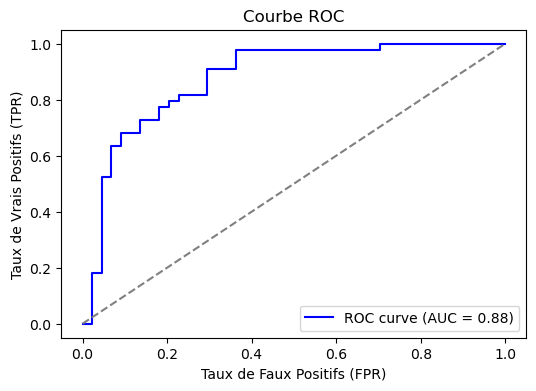

 Rapport de Classification :
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        44
           1       0.80      0.80      0.80        44

    accuracy                           0.80        88
   macro avg       0.80      0.80      0.80        88
weighted avg       0.80      0.80      0.80        88



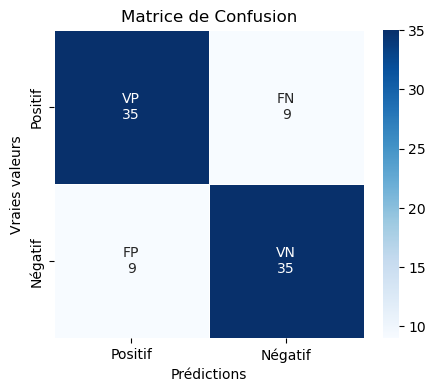

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Split des données entre features et target
X = T_data_YJ.drop(columns=["Bankrupt?"])  
y = T_data_YJ["Bankrupt?"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Sauvegarde des données train et test
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Sauvegarde dans des fichiers CSV
train_data.to_csv('/Users/benothmane/Desktop/Algo_Machine_learning_tp/train_data.csv', index=False)
test_data.to_csv('/Users/benothmane/Desktop/Algo_Machine_learning_tp/test_data.csv', index=False)

# Entraînement du modèle de régression logistique
logreg_model = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
logreg_model.fit(X_train, y_train)

# Sauvegarde du modèle
joblib.dump(logreg_model, '/Users/benothmane/Desktop/Algo_Machine_learning_tp/logreg_model.pkl')

# Prédictions sur l'ensemble du jeu de test
y_pred = logreg_model.predict(X_test)
y_proba = logreg_model.predict_proba(X_test)[:, 1]  # Probabilités pour la classe 1

# Affichage des prédictions et des probabilités arrondies à 2 décimales
print("Prédictions sur l'ensemble du jeu de test :")
print(y_pred)  # Affiche les prédictions

# Affichage des probabilités sous forme de nombres décimaux avec 2 décimales
print("\nProbabilités des prédictions (pour la classe 1) :")
print(np.round(y_proba[:40], 2))  # Affiche les probabilités pour les 40 premières données arrondies à 2 décimales

# Courbe ROC sur l'ensemble du jeu de test
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Diagonale aléatoire
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Courbe ROC")
plt.legend(loc="lower right")
plt.show()


# Rapport de classification sur l'ensemble du jeu de test
print(" Rapport de Classification :\n", classification_report(y_test, y_pred))

# Matrice de confusion sur l'ensemble du jeu de test

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

# Réorganisation des valeurs pour correspondre au format du tableau demandé
labels = [["VP\n{}".format(conf_matrix[1, 1]), "FN\n{}".format(conf_matrix[1, 0])],
          ["FP\n{}".format(conf_matrix[0, 1]), "VN\n{}".format(conf_matrix[0, 0])]]

# Création de la heatmap avec les annotations personnalisées
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=labels, fmt="", cmap="Blues", xticklabels=["Positif", "Négatif"], 
            yticklabels=["Positif", "Négatif"], cbar=True, linewidths=0.5)

# Ajout des labels
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de Confusion")

plt.show()
